In [1]:
!pip -q install pandas numpy scikit-learn openpyxl joblib gradio==4.44.1 matplotlib

import os, json
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

# Ambil nama file yang diupload
file_name = list(uploaded.keys())[0]
file_name

Saving Raisin_Dataset.xlsx to Raisin_Dataset.xlsx


'Raisin_Dataset.xlsx'

In [3]:
df = pd.read_excel(file_name)
print("Shape:", df.shape)
df.head()

Shape: (900, 8)


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [4]:
df.columns = [c.strip() for c in df.columns]  # rapikan spasi
print("Columns:", df.columns.tolist())

target_col = "Class"  # <-- ubah kalau kolom label berbeda

# buang missing value (kalau ada)
df = df.dropna().reset_index(drop=True)

# cek value kelas
print("Unique classes:", df[target_col].unique())
df[target_col].value_counts()

Columns: ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter', 'Class']
Unique classes: ['Kecimen' 'Besni']


,count
Class,
Kecimen,450
Besni,450


In [5]:
X = df.drop(columns=[target_col])
y = df[target_col].astype(str)

# pastikan semua fitur numeric
for c in X.columns:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X = X.dropna()
y = y.loc[X.index]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (900, 7)
y shape: (900,)


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (720, 7) Test: (180, 7)


Best K: 6 Accuracy: 0.8888888888888888


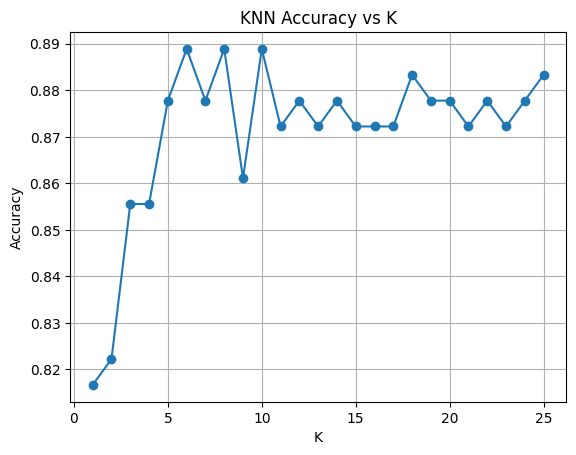

In [7]:
k_list = list(range(1, 26))
acc_list = []

for k in k_list:
    model = KNeighborsClassifier(n_neighbors=k, metric="manhattan")
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    acc_list.append(accuracy_score(y_test, pred))

best_k = k_list[int(np.argmax(acc_list))]
best_acc = max(acc_list)

print("Best K:", best_k, "Accuracy:", best_acc)

plt.figure()
plt.plot(k_list, acc_list, marker='o')
plt.title("KNN Accuracy vs K")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

Accuracy: 0.8888888888888888

Classification Report:
               precision    recall  f1-score   support

       Besni       0.93      0.84      0.88        90
     Kecimen       0.86      0.93      0.89        90

    accuracy                           0.89       180
   macro avg       0.89      0.89      0.89       180
weighted avg       0.89      0.89      0.89       180

Confusion Matrix:
 [[76 14]
 [ 6 84]]


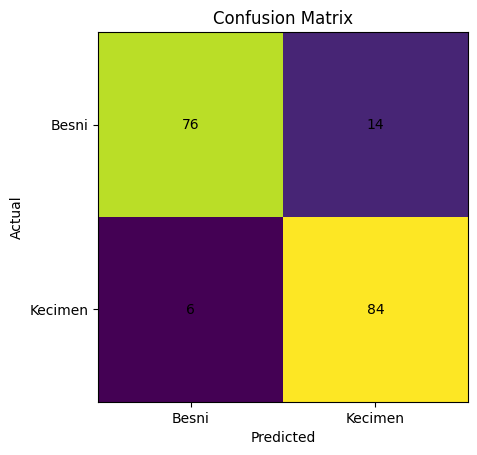

In [8]:
knn = KNeighborsClassifier(n_neighbors=best_k, metric="manhattan")
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
print("Confusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xticks(range(len(sorted(y.unique()))), sorted(y.unique()))
plt.yticks(range(len(sorted(y.unique()))), sorted(y.unique()))
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.show()

In [9]:
os.makedirs("models", exist_ok=True)

joblib.dump(knn, "models/knn_model.joblib")
joblib.dump(scaler, "models/scaler.joblib")

metadata = {
    "features": list(X.columns),
    "target_col": target_col,
    "classes": sorted(y.unique()),
    "best_k": int(best_k),
    "metric": "manhattan",
    "test_accuracy": float(best_acc)
}

with open("models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
print("- models/knn_model.joblib")
print("- models/scaler.joblib")
print("- models/metadata.json")
metadata

Saved:
- models/knn_model.joblib
- models/scaler.joblib
- models/metadata.json


{'features': ['Area',
  'MajorAxisLength',
  'MinorAxisLength',
  'Eccentricity',
  'ConvexArea',
  'Extent',
  'Perimeter'],
 'target_col': 'Class',
 'classes': ['Besni', 'Kecimen'],
 'best_k': 6,
 'metric': 'manhattan',
 'test_accuracy': 0.8888888888888888}

In [10]:
!pip uninstall -y gradio huggingface_hub
!pip install gradio==4.29.0 huggingface_hub==0.23.2

import json, joblib
import numpy as np
import pandas as pd
import gradio as gr
import matplotlib.pyplot as plt

# ===== Load artifacts =====
knn = joblib.load("models/knn_model.joblib")
scaler = joblib.load("models/scaler.joblib")
with open("models/metadata.json", "r") as f:
    metadata = json.load(f)

FEATURES = metadata["features"]  # ['Area','MajorAxisLength',...]
CLASSES  = metadata["classes"]   # ['Besni','Kecimen'] (atau kebalik)

# ===== (Opsional) Default values dari dataset kamu =====
# Kalau kamu masih punya df di notebook, ini akan otomatis dipakai.
# Kalau tidak ada df, UI tetap jalan pakai default angka 0.
try:
    df  # noqa
    defaults = {c: float(df[c].median()) for c in FEATURES}
    minmax   = {c: (float(df[c].min()), float(df[c].max())) for c in FEATURES}
except:
    defaults = {c: 0.0 for c in FEATURES}
    minmax   = {c: (0.0, 1.0) for c in FEATURES}

def _clamp(v, lo, hi):
    try:
        v = float(v)
    except:
        v = lo
    return max(lo, min(hi, v))

def predict_and_explain(area, major, minor, ecc, convex, extent, perim):
    # rapikan input + clamp ke range dataset (biar user ga input terlalu ekstrem)
    vals = {
        "Area": area,
        "MajorAxisLength": major,
        "MinorAxisLength": minor,
        "Eccentricity": ecc,
        "ConvexArea": convex,
        "Extent": extent,
        "Perimeter": perim
    }

    x_list = []
    for feat in FEATURES:
        lo, hi = minmax.get(feat, (None, None))
        v = vals[feat]
        if lo is not None and hi is not None:
            v = _clamp(v, lo, hi)
        else:
            v = float(v)
        x_list.append(v)

    x = np.array(x_list, dtype=float).reshape(1, -1)
    x_scaled = scaler.transform(x)

    pred = knn.predict(x_scaled)[0]

    # proba
    if hasattr(knn, "predict_proba"):
        proba = knn.predict_proba(x_scaled)[0]
        proba_map = {CLASSES[i]: float(proba[i]) for i in range(len(CLASSES))}
    else:
        proba_map = {c: 0.0 for c in CLASSES}

    # confidence tertinggi
    best_class = max(proba_map, key=proba_map.get)
    best_conf = proba_map[best_class]

    # confidence text badge
    if best_conf >= 0.85:
        conf_badge = "High ✅"
    elif best_conf >= 0.65:
        conf_badge = "Medium ⚠️"
    else:
        conf_badge = "Low ❗"

    # tabel probabilitas
    df_proba = pd.DataFrame(
        [{"Class": k, "Probability": v} for k, v in sorted(proba_map.items(), key=lambda x: -x[1])]
    )

    # chart probabilitas
    fig = plt.figure()
    plt.bar(df_proba["Class"], df_proba["Probability"])
    plt.ylim(0, 1)
    plt.title("Prediction Probability")
    plt.xlabel("Class")
    plt.ylabel("Probability")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()

    # detail ringkas
    details = (
        f"**Predicted:** `{pred}`\n\n"
        f"**Top Confidence:** `{best_class}` = `{best_conf:.2%}`\n\n"
        f"**Confidence Level:** **{conf_badge}**\n\n"
        f"**Model:** KNN (metric=`{metadata.get('metric','-')}`, K=`{metadata.get('best_k','-')}`)\n"
    )

    # return: result, confidence label, table, chart, details
    return pred, proba_map, df_proba, fig, details

# ============ UI LEBIH MENARIK (Blocks) ============
theme = gr.themes.Soft(
    primary_hue="indigo",
    secondary_hue="blue",
    neutral_hue="slate",
)

with gr.Blocks(theme=theme, css="""
#title {text-align:center; margin-bottom: 8px;}
.card {border-radius: 18px; padding: 14px;}
.small {opacity: 0.85; font-size: 0.95rem;}
""") as demo:

    gr.Markdown(
        """
        <h1 id="title">🍇 Raisin Classification (Kecimen vs Besni)</h1>
        <p class="small" style="text-align:center;">
        Masukkan fitur raisin, lalu klik <b>Predict</b> untuk melihat hasil, confidence, dan probabilitas.
        </p>
        """
    )

    with gr.Row():
        # === LEFT: Input ===
        with gr.Column(scale=6):
            with gr.Group():
                gr.Markdown("### 🧾 Input Features")
                with gr.Row():
                    area   = gr.Number(label="Area", value=defaults["Area"])
                    convex = gr.Number(label="ConvexArea", value=defaults["ConvexArea"])
                with gr.Row():
                    major  = gr.Number(label="MajorAxisLength", value=defaults["MajorAxisLength"])
                    minor  = gr.Number(label="MinorAxisLength", value=defaults["MinorAxisLength"])
                with gr.Row():
                    ecc    = gr.Number(label="Eccentricity", value=defaults["Eccentricity"])
                    extent = gr.Number(label="Extent", value=defaults["Extent"])
                with gr.Row():
                    perim  = gr.Number(label="Perimeter", value=defaults["Perimeter"])

                with gr.Row():
                    btn_pred = gr.Button("🔮 Predict", variant="primary")
                    btn_clear = gr.Button("🧹 Clear", variant="secondary")

                gr.Markdown(
                    """
                    <div class="small">
                    Tips: nilai input akan otomatis di-<i>clamp</i> ke rentang min–max dataset (kalau <code>df</code> ada di notebook).
                    </div>
                    """
                )

        # === RIGHT: Output ===
        with gr.Column(scale=6):
            with gr.Group():
                gr.Markdown("### ✅ Prediction Result")
                pred_out = gr.Textbox(label="Predicted Class", interactive=False)
                conf_out = gr.Label(label="Confidence", num_top_classes=2)

            with gr.Group():
                gr.Markdown("### 📊 Probability Details")
                proba_table = gr.Dataframe(
                    headers=["Class", "Probability"],
                    datatype=["str", "number"],
                    interactive=False,
                    wrap=True
                )
                proba_plot = gr.Plot()

            with gr.Group():
                gr.Markdown("### 📝 Model Notes")
                details_md = gr.Markdown()

    # Examples (opsional): contoh input dari median + variasi kecil
    ex1 = [defaults["Area"], defaults["MajorAxisLength"], defaults["MinorAxisLength"], defaults["Eccentricity"],
           defaults["ConvexArea"], defaults["Extent"], defaults["Perimeter"]]
    ex2 = [defaults["Area"]*0.95, defaults["MajorAxisLength"]*1.02, defaults["MinorAxisLength"]*0.98, defaults["Eccentricity"]*1.01,
           defaults["ConvexArea"]*0.97, defaults["Extent"]*1.03, defaults["Perimeter"]*0.96]
    ex3 = [defaults["Area"]*1.08, defaults["MajorAxisLength"]*0.97, defaults["MinorAxisLength"]*1.03, defaults["Eccentricity"]*0.99,
           defaults["ConvexArea"]*1.05, defaults["Extent"]*0.95, defaults["Perimeter"]*1.04]

    gr.Examples(
        examples=[ex1, ex2, ex3],
        inputs=[area, major, minor, ecc, convex, extent, perim],
        label="✨ Quick Examples (klik untuk autofill)"
    )

    # Actions
    btn_pred.click(
        fn=predict_and_explain,
        inputs=[area, major, minor, ecc, convex, extent, perim],
        outputs=[pred_out, conf_out, proba_table, proba_plot, details_md]
    )

    def clear_all():
        return (
            defaults["Area"], defaults["MajorAxisLength"], defaults["MinorAxisLength"], defaults["Eccentricity"],
            defaults["ConvexArea"], defaults["Extent"], defaults["Perimeter"],
            "", {}, pd.DataFrame(columns=["Class","Probability"]), None, ""
        )

    btn_clear.click(
        fn=clear_all,
        inputs=[],
        outputs=[area, major, minor, ecc, convex, extent, perim,
                 pred_out, conf_out, proba_table, proba_plot, details_md]
    )

demo.launch(share=True)

Found existing installation: gradio 4.44.1
Uninstalling gradio-4.44.1:
  Successfully uninstalled gradio-4.44.1
Found existing installation: huggingface-hub 0.23.2
Uninstalling huggingface-hub-0.23.2:
  Successfully uninstalled huggingface-hub-0.23.2
  Using cached gradio-4.29.0-py3-none-any.whl.metadata (15 kB)
  Using cached huggingface_hub-0.23.2-py3-none-any.whl.metadata (12 kB)
  Using cached gradio_client-0.16.1-py3-none-any.whl.metadata (7.1 kB)
Using cached gradio-4.29.0-py3-none-any.whl (12.3 MB)
Using cached huggingface_hub-0.23.2-py3-none-any.whl (401 kB)
Using cached gradio_client-0.16.1-py3-none-any.whl (314 kB)
  Attempting uninstall: gradio-client
    Found existing installation: gradio_client 1.3.0
    Uninstalling gradio_client-1.3.0:
      Successfully uninstalled gradio_client-1.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
peft 0.18.1 